# Computer Vision - Kelompok 7

### Library
---

In [1]:
import cv2
import os
import numpy as np
import random
import yaml
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from glob import glob

### Load Data
---

In [2]:
img_dir = 'images'
label_dir = 'labels-YOLO'
pothole_dir = 'pothole_dataset'

### Data Preprocessing
---

Set Training, Validation, Parameter

In [3]:
train_ratio = 0.70
val_ratio = 0.15

param = {
    'sat_min': -30,
    'sat_max': 30,
    'val_min': -40,
    'val_max': 40,
    'mean': 0,
    'std_dev': 15,
}

Making Pothole Folder and Data Augmentation

In [4]:
for i in ['train', 'validation', 'test']:
    for j in ['images', 'labels']:
        os.makedirs(os.path.join(pothole_dir, i, j), exist_ok=True)
print("1. Making Pothole Folder and Data Augmentation")

def augmentating(img):
    # HSV - Saturation and Brightness (Value) Adjustment
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) 
    hue, sat, val = cv2.split(hsv)

    sat_change = random.randint(param['sat_min'], param['sat_max'])
    val_change = random.randint(param['val_min'], param['val_max'])
    sat_aug = cv2.add(sat, sat_change)
    val_aug = cv2.add(val, val_change)

    final_hsv = cv2.merge((hue, sat_aug, val_aug))
    img_aug = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)

    # Gaussian Noise Application
    # noise = np.zeros(img_aug.shape, np.int8)
    # cv2.randn(noise, param['mean'], param['std_dev'])
    # img_aug = cv2.add(img_aug, noise, dtype=cv2.CV_8UC3)

    # Gaussian Blur Application
    # img_aug = cv2.GaussianBlur(img_aug, (3, 3), 0)

    return img_aug

1. Making Pothole Folder and Data Augmentation


Preprocessing Function

In [5]:
def preprocessing(img_path, current_folder):
    file = os.path.basename(img_path)
    label_path = os.path.join(label_dir, file.replace('.jpg', '.txt'))
    
    # 1. Load gambar asli
    img = cv2.imread(img_path)
    if img is None:
        return
        
    pothole_label = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                data = line.split()
                cls = int(data[0])

                # Filter hanya kelas Pothole (0) sesuai kebutuhan Kelompok 7
                if cls == 0:
                    pothole_label.append(line.strip())

    # Jika gambar tidak mengandung lubang jalan sama sekali, lewati
    if not pothole_label:
        return
    
    # 2. Jalankan augmentasi warna HSV kalian (Piksel tetap berkategori uint8 asli)
    img_aug = augmentating(img)
    
    # 3. Resize langsung ke ukuran target input YOLOv8 (640x640)
    img_resized = cv2.resize(img_aug, (640, 640))
    
    # --- PERBAIKAN: Jangan lakukan normalisasi / pembagian 255 manual ---
    # Biarkan data berupa gambar matriks standar standar OpenCV agar YOLOv8 yang mengurusnya secara internal
    
    # 4. Simpan gambar dan label secara bersih ke folder tujuan
    cv2.imwrite(os.path.join(pothole_dir, current_folder, 'images', file), img_resized)
    with open(os.path.join(pothole_dir, current_folder, 'labels', file.replace('.jpg', '.txt')), 'w') as f:
        f.write("\n".join(pothole_label))

Dataset Training, Testing, Validation (70/15/15)

In [6]:
all_files = glob(os.path.join(img_dir, "*.jpg"))

In [7]:
random.seed(42)
random.shuffle(all_files)
total_files = len(all_files)
train_end = int(total_files * train_ratio)
val_end = int(total_files * (train_ratio + val_ratio))

curr_train = 0
curr_val = 0
curr_test = 0

Processed File Seperated into different folder

In [8]:
for i, file_path in enumerate(all_files):
    if i < train_end:
        if curr_train == 0:
            print("2. Preprocessing all files on train dataset.")
            curr_train = 1
        current_folder = 'train'
    elif i < val_end:
        if curr_val == 0:
            print("3. Preprocessing all files on validation dataset.")
            curr_val = 1
        current_folder = 'validation'
    else:
        if curr_test == 0:
            print("4. Preprocessing all files on test dataset.")
            curr_test = 1
        current_folder = 'test'
    
    preprocessing(file_path, current_folder)


2. Preprocessing all files on train dataset.
3. Preprocessing all files on validation dataset.
4. Preprocessing all files on test dataset.


In [9]:
print(f"\nAll Data has been succesfully processed")
print(f"Data stored at: {pothole_dir}")
print(f"Total images: {total_files}")


All Data has been succesfully processed
Data stored at: pothole_dataset
Total images: 2009


### Modelling - YOLOv8
---

Making File Configuration (data.yaml)

In [10]:
data_yaml = {
    'path': os.path.abspath(pothole_dir),
    'train': 'train/images',
    'val': 'validation/images',
    'test': 'test/images',
    'nc': 1,
    'names': {0: 'pothole'}
}

yaml_path = os.path.join(pothole_dir, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"File data.yaml Successfully Configurated at : {yaml_path}")

File data.yaml Successfully Configurated at : pothole_dataset\data.yaml


Load YOLOv8 and Training Model

In [24]:
import shutil
if os.path.exists('runs'):
    shutil.rmtree('runs')   # hapus semua hasil training lama

import torch
torch.cuda.empty_cache()

model = YOLO('yolov8m.pt')

# Memulai proses training optimal
results = model.train(
    data=os.path.abspath(os.path.join(pothole_dir, 'data.yaml')),
    epochs=200,
    patience=30,    
    imgsz=640,
    batch=16,           # RTX 4060 kuat, kembalikan ke 16
    device=0,

    # Optimizer — gunakan default SGD dulu
    # optimizer='AdamW',  # COMMENT dulu ini
    lr0=0.01,           # default YOLO
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3,
    # Augmentasi spatial
    mosaic=1.0,
    mixup=0.15,          # tambah mixup
    copy_paste=0.1,      # bantu deteksi objek kecil
    degrees=15.0,        # naikkan sedikit dari 10
    scale=0.6,
    fliplr=0.5,
    flipud=0.3,
    translate=0.1,
    hsv_s=0.7,
    hsv_v=0.4,
    
    close_mosaic=15,
    
    name='yolov8_pothole_kel7'
)


Ultralytics 8.4.53  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset\data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov

In [27]:
train_imgs = glob(os.path.join(pothole_dir, 'train', 'images', '*.jpg'))
val_imgs   = glob(os.path.join(pothole_dir, 'validation', 'images', '*.jpg'))
test_imgs  = glob(os.path.join(pothole_dir, 'test', 'images', '*.jpg'))

print(f"Train : {len(train_imgs)} gambar")
print(f"Val   : {len(val_imgs)} gambar")
print(f"Test  : {len(test_imgs)} gambar")
print(f"Total : {len(train_imgs) + len(val_imgs) + len(test_imgs)} gambar")

Train : 553 gambar
Val   : 120 gambar
Test  : 122 gambar
Total : 795 gambar


### Evaluation Metric and Exporting Model
---

Total Loss and Accuracy Plotting

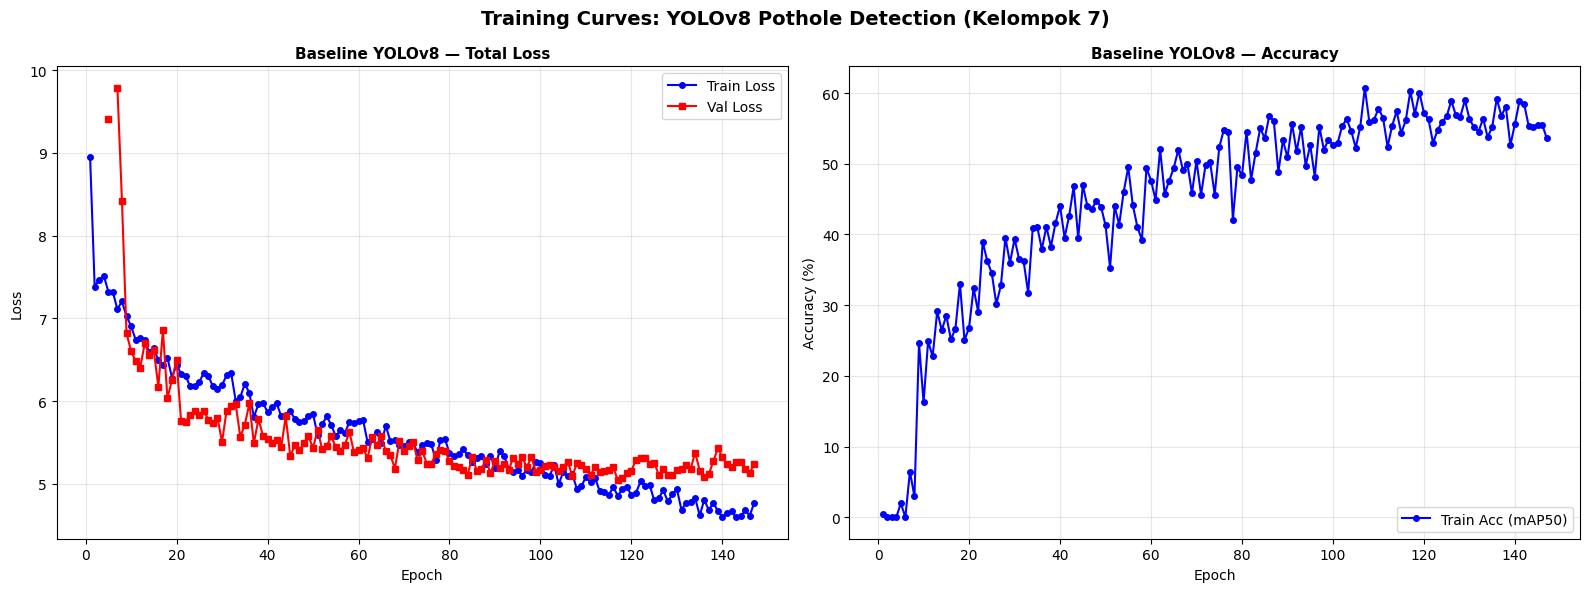

In [25]:
# Force Graph
%matplotlib inline

# Search Training Result Folder
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    csv_path = os.path.join(latest_folder, 'results.csv')
    
    if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip() # Clear Whitespace
        
        epochs = df['epoch']
        
        # Total Loss Calculation YOLOv8 (box_loss + cls_loss + dfl_loss)
        train_total_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
        val_total_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']
        
        # mAP50 Metric (%)
        accuracy_map50 = df['metrics/mAP50(B)'] * 100
        
        # 2 Graph Plotting
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Training Curves: YOLOv8 Pothole Detection (Kelompok 7)', fontweight='bold', fontsize=14)
        
        # --- Graph 1 : Total Loss Curve (Left) ---
        axes[0].plot(epochs, train_total_loss, 'b-o', markersize=4, label='Train Loss')
        axes[0].plot(epochs, val_total_loss, 'r-s', markersize=4, label='Val Loss')
        axes[0].set_title('Baseline YOLOv8 — Total Loss', fontweight='bold', fontsize=11)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # --- Graph 2: Accuracy / mAP50 Curve (Right) ---
        axes[1].plot(epochs, accuracy_map50, 'b-o', markersize=4, label='Train Acc (mAP50)')
        axes[1].set_title('Baseline YOLOv8 — Accuracy', fontweight='bold', fontsize=11)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].legend(loc='lower right')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("result.csv doesn't have any value.")
else:
    print("No Training Folder was Found")

Accuracy, Precision, Recall, and F1-Score

In [26]:
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    best_weight = os.path.join(latest_folder, 'weights', 'best.pt')
    
    if os.path.exists(best_weight):
        # Load Saved Model
        saved_model = YOLO(best_weight)
        
        print("--- Evaluation Metric Model ---")
        metrics = saved_model.val(split='test', conf=0.25, iou=0.5, verbose=False)
        
        # 2. Extract Metric from YOLOv8
        precision = metrics.results_dict['metrics/precision(B)'] * 100
        recall = metrics.results_dict['metrics/recall(B)'] * 100
        map50 = metrics.results_dict['metrics/mAP50(B)'] * 100
        map95 = metrics.results_dict['metrics/mAP50-95(B)'] * 100
        
        # Calculating F1 Score
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Set map50 as Accuracy
        accuracy = map50 
        
        # Show Result : Accuracy, Precision, Recall, F1-Score
        print(f"\n Evaluation Result")
        print(f"1. Accuracy (mAP50)     : {accuracy:.2f}%")
        print(f"2. Precision            : {precision:.2f}%")
        print(f"3. Recall               : {recall:.2f}%")
        print(f"4. F1-Score             : {f1_score:.2f}%")
        print(f"5. mAP50-95              : {map95:.2f}%")
        
    else:
        print("File weights 'best.pt' belum terbentuk.")
else:
    print("No Folder Training was Found.")

--- Evaluation Metric Model ---
Ultralytics 8.4.53  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1258.4129.8 MB/s, size: 121.7 KB)
val: Scanning D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset\test\labels.cache... 122 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 122/122  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.5it/s 5.3s0.3s5
                   all        122        198      0.601       0.48      0.397      0.165
Speed: 2.0ms preprocess, 17.6ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\runs\detect\val

 Evaluation Result
1. Accuracy (mAP50)     : 39.71%
2. Precision            : 60.1

Prediction Potholes and Calculate Road Health Index (RHI)


image 1/1 d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset\test\images\vlcsnap-2025-02-18-17h11m22s054.jpg: 640x640 2 potholes, 5.0ms
Speed: 1.8ms preprocess, 5.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


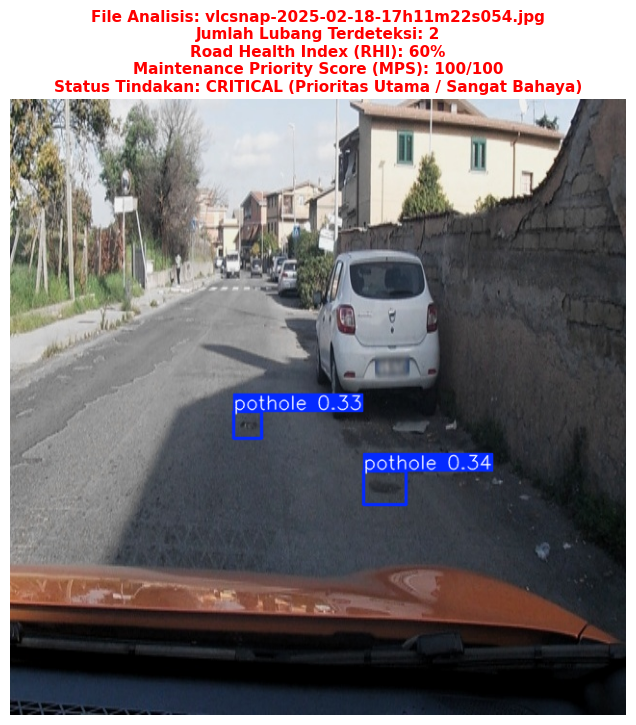

In [14]:
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    best_weight = os.path.join(latest_folder, 'weights', 'best.pt')
    
    if os.path.exists(best_weight):
        final_model = YOLO(best_weight)
        
        test_images_dir = os.path.join(pothole_dir, 'test', 'images')
        all_test_images = os.listdir(test_images_dir)
        random_image = random.choice(all_test_images)
        sample_path = os.path.join(test_images_dir, random_image)
        
        # Predict Detection
        predictions = final_model(sample_path)
        
        for result in predictions:
            img_bgr = result.plot()
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            num_potholes = len(result.boxes)
            
            # --- ROAD HEALTH INDEX (RHI) ---
            base_health = 100
            deduction_per_pothole = 20 
            rhi_score = max(0, base_health - (num_potholes * deduction_per_pothole))
            
            # --- MAINTENANCE PRIORITY SCORE (MPS) ---
            # Severity of the Potholes based on the size of Bounding Box
            total_severity_score = 0
            
            if num_potholes > 0:
                for box in result.boxes:
                    # Width and Height of Bounding Box
                    w_box = box.xywh[0][2].item()
                    h_box = box.xywh[0][3].item()
                    
                    # Menghitung perkiraan persentase luas area lubang terhadap ukuran keseluruhan frame gambar
                    box_area_percentage = (w_box * h_box) * 100
                    
                    # Bobot pengali: Lubang berukuran besar (> 5% dari frame jalan) akan memberikan skor prioritas perbaikan yang berlipat ganda
                    if box_area_percentage > 5.0:
                        severity_weight = 3.0  # Kategori lubang besar/dalam
                    else:
                        severity_weight = 1.0  # Kategori lubang kecil
                        
                    total_severity_score += (box_area_percentage * severity_weight)
            
            # Normalisasi Maintenance Priority Score agar berada di rentang skala indeks 0 hingga 100
            mps_score = min(100, int(total_severity_score * 5))
            
            # Menentukan label keputusan prioritas perbaikan struktural jalan
            if mps_score >= 70 or rhi_score <= 40:
                priority_status = "CRITICAL (Prioritas Utama / Sangat Bahaya)"
                color_text = 'red'
            elif mps_score >= 40 or rhi_score <= 70:
                priority_status = "MEDIUM (Perbaikan Berkala)"
                color_text = 'darkorange'
            else:
                priority_status = "LOW (Perawatan Rutin Lingkungan)"
                color_text = 'green'
                
            # Menampilkan hasil visualisasi analisis sistem terpadu
            plt.figure(figsize=(11, 8))
            plt.imshow(img_rgb)
            
            title_info = (
                f"File Analisis: {random_image}\n"
                f"Jumlah Lubang Terdeteksi: {num_potholes}\n"
                f"Road Health Index (RHI): {rhi_score}%\n"
                f"Maintenance Priority Score (MPS): {mps_score}/100\n"
                f"Status Tindakan: {priority_status}"
            )
            plt.title(title_info, fontweight='bold', fontsize=11, color=color_text if color_text != 'darkorange' else 'orange')
            plt.axis('off')
            plt.show()
    else:
        print("❌ File weights 'best.pt' tidak ditemukan.")